# Setup

In [1]:
%matplotlib inline

import copy
import json
import matplotlib.pyplot as plt
import numpy as np
import os

# Evaluation functions

In [2]:
def get_confusion_matrix(y_true1d, y_pred1d, n_classes=2):
    """
    Calculates the confusion matrix given ground truths and predictions (lists or 1D arrays)
    """
    assert len(y_true1d) == len(y_pred1d), f'Inputs y_true1d and y_pred1d must have the same length (got {len(y_true1d)} and {len(y_pred1d)})'
    
    cmatrix = np.zeros((n_classes, n_classes), dtype=int)
    for i in range(len(y_true1d)):
        true_label = y_true1d[i]  # ground truth (row index)
        pred_label = y_pred1d[i]  # predicted truth (col index)
        cmatrix[true_label, pred_label] += 1
    
    assert cmatrix.sum() == len(y_true1d), 'Check that class indices are in [0, n_classes).'
    return cmatrix

In [3]:
def compute_precision_recall(cmatrix, balanced=False, verbose=False):
    assert (cmatrix.ndim == 2) and (cmatrix.shape[0] == cmatrix.shape[1]), f'cmatrix must be square 2-D (got shape {cmatrix.shape})'
    cmatrix = cmatrix.copy()  # we will be altering cmatrix - make a copy to avoid changing the original

    n_classes = cmatrix.shape[0]
    
    result = {
        'pre': {class_idx: 0.0 for class_idx in range(n_classes)},
        'rec': {class_idx: 0.0 for class_idx in range(n_classes)},
        #'f1': {class_idx: 0.0 for class_idx in range(n_classes)}
    }

    idxarr = np.arange(n_classes)  # used for indexing below
    for class_idx in range(n_classes):
        nonidx = idxarr[idxarr != class_idx]

        # Carve out TP, FP, FN, TN from the full matrix
        # (turns the problem into binary classification relative to class_idx)
        
        # True positives are the entry in [class_idx, class_idx]
        class_TP = cmatrix[class_idx, class_idx]

        # False negatives
        fn_submatrix = cmatrix[class_idx, nonidx]  # ground truth: row class_idx; predicted: all cols except cid
        class_FN     = fn_submatrix.sum()

        # False positives
        fp_submatrix = cmatrix[nonidx, class_idx]  # ground truth: all rows in nonidx; predicted: col class_idx
        class_FP = fp_submatrix.sum()

        # True negatives
        tn_submatrix = cmatrix[nonidx, :][:, nonidx]  # ground truth: all rows in nonidx; predicted: all cols in nonidx
        class_TN = tn_submatrix.sum()

        # Build 2x2 confusion matrix (binary classification relative to class_idx)
        binary_cmatrix = np.array([
            [class_TN, class_FP],
            [class_FN, class_TP]
        ]).astype(np.float32)

        # Optional balancing: the actual technique
        if balanced:
            # Balance the row sums in the binary confusion matrix equivalent
            row_sums = binary_cmatrix.sum(axis=1)  # shape (2,)
            max_row_idx = int(np.argmax(row_sums))
            max_row_sum = row_sums[max_row_idx]
            
            for i, row_sum in enumerate(row_sums):
                if row_sum > 0:
                    scaling_factor = max_row_sum / row_sum
                    binary_cmatrix[i, :] *= scaling_factor

            # Re-read the TP, FP, FN, TN components after scaling
            class_TN = binary_cmatrix[0, 0]
            class_FP = binary_cmatrix[0, 1]
            class_FN = binary_cmatrix[1, 0]
            class_TP = binary_cmatrix[1, 1]
        
        # Compute metrics
        pre = (class_TP) / (class_TP + class_FP) if class_TP + class_FP > 0 else 0.0
        rec = (class_TP) / (class_TP + class_FN) if class_TP + class_FN > 0 else 0.0

        result['pre'][class_idx] = pre
        result['rec'][class_idx] = rec

    if verbose:
        for class_idx in range(n_classes):
            pre = result['pre'][class_idx]
            rec = result['rec'][class_idx]
            print(f'Class {class_idx} metrics: pre={pre:.4f} | rec={rec:.4f}')
    
    return result

In [4]:
def plot_metrics_distributions(resdict):
    plt.figure(figsize=(6,4))
    plt.subplot(2,2,1); dlist = resdict['pre'][0]
    plt.hist(dlist, rwidth=0.9); plt.title(f'Precision (std={np.std(dlist):.3f})'); plt.ylabel('NORMAL (0)')
    plt.subplot(2,2,2); dlist = resdict['rec'][0]
    plt.hist(resdict['rec'][0], rwidth=0.9); plt.title(f'Recall (std={np.std(dlist):.3f})');
    plt.subplot(2,2,3); dlist = resdict['pre'][1]
    plt.hist(resdict['pre'][1], rwidth=0.9); plt.title(f'Precision (std={np.std(dlist):.3f})'); plt.ylabel('ABNORMAL (1)')
    plt.subplot(2,2,4); dlist = resdict['rec'][1]
    plt.hist(resdict['rec'][1], rwidth=0.9); plt.title(f'Recall (std={np.std(dlist):.3f})');
    plt.tight_layout()
    return plt

# Abstract Model and Data

To represent an incoming data point, we define a simple `AbstractPoint` with a `label` (integer) and a `drift` parameter (a float between 0 and 1 that captures how difficult the point is to predict):

In [6]:
class AbstractPoint(dict):
    def __init__(self, label: int, drift: float):
        dict.__init__(self, label=label, drift=max(0.0, min(1.0, drift)))
        self.label = label
        self.drift = drift

We also define an `AbstractModel`, which holds the per-class recall rates and uses them to determine whether each incoming point is classified correctly.

Inside `predict()`, the `drift` parameter scales the class recall toward zero as it increases, effectively making the point "harder" for the model to classify the data. When `drift = 0`, the recall is applied unchanged.

In [7]:
class AbstractModel:
    def __init__(self, class_recalls: list):
        assert len(class_recalls) == 2
        self.class_recalls = class_recalls

    def predict(self, x: AbstractPoint):
        # Modify the class recall by the amount of drift, where drift is between 0 and 1.
        # When drift is 0, class_recall is unchanged. As drift -> 1, class_recall -> 0.
        adjusted_recall = self.class_recalls[x.label] * (1 - x.drift)
        
        return x.label if (np.random.random() < adjusted_recall) else 1 - x.label

In [8]:
recall_0 = 0.94
recall_1 = 0.75

model = AbstractModel(class_recalls=[recall_0, recall_1])

The model takes incoming data one point at a time and returns a prediction.

In [9]:
np.random.seed(412)

p0 = AbstractPoint(label=0, drift=0.0)
p1 = AbstractPoint(label=1, drift=0.0)

model.predict(p0), model.predict(p1)

(1, 0)

In [10]:
# Define a helper function that creates a prediction episode by pairing each point with its prediction.

def generate_episode(model, label=0, drift=0.0):
    if label in [0, 'normal']:
        p = AbstractPoint(label=0, drift=drift)
        prediction = model.predict(p)
    elif label in [1, 'abnormal']:
        p = AbstractPoint(label=1, drift=drift)
        prediction = model.predict(p)
    else:
        raise ValueError(f'Unsupported event type: {label}')
    return (p, prediction)  # returns: point (with ground truth label), prediction

generate_episode(model, label=1, drift=0)

({'label': 1, 'drift': 0.0}, 1)

# Simulation scenarios

## Balanced data scenario

We simulate a perfectly balanced dataset with equal representation from both classes (5000 samples each). We generate prediction episodes for each class and compute the metrics.

In [11]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_SAMPLES = 10000
DRIFT = 0.0

# Model performance parameters - set using RECALL for NORMAL (0) and ABNORMAL (1)
NORMAL_RECALL = 0.94
ABNORMAL_RECALL = 0.75

model = AbstractModel(class_recalls=[NORMAL_RECALL, ABNORMAL_RECALL])

# Create a balanced test set
balanced_data = {
    0: [],  # normal samples
    1: []  # abnormal samples
}
for i in range(N_SAMPLES//2):
    balanced_data[0].append(generate_episode(model, label=0, drift=DRIFT))
    balanced_data[1].append(generate_episode(model, label=1, drift=DRIFT))

len(balanced_data[0]), len(balanced_data[1]), len(balanced_data[0]) + len(balanced_data[1])

(5000, 5000, 10000)

In [13]:
# Evaluate model performance
y_true1d = [event[0].label for event in balanced_data[0]] + [episode[0].label for episode in balanced_data[1]]
y_pred1d = [event[1] for event in balanced_data[0]] + [episode[1] for episode in balanced_data[1]]

cmatrix = get_confusion_matrix(y_true1d, y_pred1d, n_classes=2)
cmatrix

array([[4695,  305],
       [1211, 3789]])

In [14]:
# Theoretical - true model metrics on perfectly balanced dataset
R0 = NORMAL_RECALL
R1 = ABNORMAL_RECALL

P0 = R0 / (R0 + 1 - R1)
P1 = R1 / (R1 + 1 - R0)

print(f'Class 0 metrics: pre={P0:.4f} | rec={R0:.4f}')
print(f'Class 1 metrics: pre={P1:.4f} | rec={R1:.4f}')

Class 0 metrics: pre=0.7899 | rec=0.9400
Class 1 metrics: pre=0.9259 | rec=0.7500


In [15]:
# The simulated metrics match the theoretical values closely
compute_precision_recall(cmatrix, balanced=False, verbose=True)

Class 0 metrics: pre=0.7950 | rec=0.9390
Class 1 metrics: pre=0.9255 | rec=0.7578


{'pre': {0: 0.7949542837792076, 1: 0.9255007327796776},
 'rec': {0: 0.939, 1: 0.7578}}

## Anomaly detection scenario

To simulate running predictions on incoming data (common in anomaly detection), we define a helper `generate_episode()` that creates a *prediction episode* by pairing each point with its prediction. It takes a label (*normal* or *abnormal*) and optional drift, creates the appropriate `AbstractPoint p`, runs `predict(p)`, and returns the pair.

Data generation uses a two-stage process to simulate a *daily event* pattern common in in anomaly detection.

**Stage 1: Daily Episodes**

1. Each day, the number of *abnormal events* is drawn from a *Poisson distribution* with parameter `ABNORMAL_RATE` (the expected number of anomalies per day).
2. The *total number of events for that day* is drawn from a *normal distribution* with mean `EVENTS_RATE` and standard deviation `EVENTS_STD` proportional to that mean. The normal events are then the difference between total and abnormal counts. This gives a natural class imbalance: with `ABNORMAL_RATE = 5` and `EVENTS_RATE = 100`, approximately 5% of events are abnormal.

In [16]:
# Daily values for the occurrence of abnormal events
ABNORMAL_RATE = 5  # Poisson lambda for abnormal events per day: E(X) = lambda
ABNORMAL_PCT = 0.05 # the probability of an event being Abnormal

EVENTS_RATE = int(ABNORMAL_RATE / ABNORMAL_PCT)  # total events per day (expected: 100)
EVENTS_STD = 0.1 * EVENTS_RATE  # 10% of total events

print(f'Total episodes per day (expected): {EVENTS_RATE} (std={EVENTS_STD})')

Total episodes per day (expected): 100 (std=10.0)


In [17]:
def generate_daily_episodes(n_days, normal_recall, abnormal_recall, abnormal_rate=50, abnormal_pct=0.05, drift=0.0, events_std_alpha=0.1):
    model = AbstractModel(class_recalls=[normal_recall, abnormal_recall])

    events_rate = int(abnormal_rate / abnormal_pct)  #100  # total events per day
    events_std = events_std_alpha * events_rate  # 10% of total events
    
    data = {
        0: [],  # holds class 0 episodes (normal)
        1: []  # holds class 1 episodes (abnormal)
    }
    for i in range(n_days):
        n_abnormal = np.random.poisson(lam=abnormal_rate)
        n_total = int(np.random.normal(loc=events_rate, scale=events_std))
        n_normal = max(n_total - n_abnormal, 0)
        
        for _ in range(n_normal):
            data[0].append(generate_episode(model, label=0, drift=drift))
        for _ in range(n_abnormal):
            data[1].append(generate_episode(model, label=1, drift=drift))
    return data

**Stage 2: Multi-day Data Collection**

We collect these daily episodes over a *two-week period* (`N_DAYS = 14`), forming the test set to be used for model performance evaluation.

In [26]:
RANDOM_SEED = 42
N_DAYS = 14

# Model performance parameters - set using RECALL for NORMAL (0) and ABNORMAL (1)
NORM_REC = 0.94
ABNORM_REC = 0.75
model = AbstractModel(class_recalls=[NORM_REC, ABNORM_REC])

# Daily values for the occurrence of events
ABNORMAL_RATE = 5  # Poisson lambda for abnormal events per day: E(X) = lambda
ABNORMAL_PCT = 0.05 # the probability of an event being Abnormal

# Data drift value (between 0 and 1, reduces the recall value by this factor)
DRIFT = 0.0

#np.random.seed(RANDOM_SEED)

data = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=DRIFT,
    events_std_alpha=0.1
)

len(data[0]), len(data[1]), len(data[0]) + len(data[1])

(1356, 63, 1419)

# Performance evaluation

## Naive approach

In [27]:
y_true1d = [episode[0].label for episode in data[0]] + [episode[0].label for episode in data[1]]  # ground truths
y_pred1d = [episode[1] for episode in data[0]] + [episode[1] for episode in data[1]]  # predictions

cmatrix = get_confusion_matrix(y_true1d, y_pred1d, n_classes=2)
cmatrix

array([[1283,   73],
       [  13,   50]])

In [28]:
"""
True model performance (theoretical)
Class 0 metrics: pre=0.7950 | rec=0.9390
Class 1 metrics: pre=0.9255 | rec=0.7578

Estimated model performance (on balanced data from before - very close to theoretical)
Class 0 metrics: pre=0.7950 | rec=0.9390
Class 1 metrics: pre=0.9255 | rec=0.7578

Imbalanced data - showing several runs (without resetting random seed)
Class 0 metrics: pre=0.9946 | rec=0.9377
Class 1 metrics: pre=0.3582 | rec=0.8727

Class 0 metrics: pre=0.9880 | rec=0.9326
Class 1 metrics: pre=0.3308 | rec=0.7458

Class 0 metrics: pre=0.9900 | rec=0.9462
Class 1 metrics: pre=0.4065 | rec=0.7937
"""

# Performance on imbalanced data
compute_precision_recall(cmatrix, balanced=False, verbose=True)

Class 0 metrics: pre=0.9900 | rec=0.9462
Class 1 metrics: pre=0.4065 | rec=0.7937


{'pre': {0: 0.9899691358024691, 1: 0.4065040650406504},
 'rec': {0: 0.946165191740413, 1: 0.7936507936507936}}

We can run this simulation several times to get a sense of how much the metrics vary over time in a real-world scenario.

In [31]:
n_runs = 30

np.random.seed(RANDOM_SEED)

metric_list = []

for _ in range(n_runs):
    data = generate_daily_episodes(
        n_days=N_DAYS,
        normal_recall=NORM_REC,
        abnormal_recall=ABNORM_REC,
        abnormal_rate=ABNORMAL_RATE,
        abnormal_pct=ABNORMAL_PCT,
        drift=DRIFT,
        events_std_alpha=0.1
    )

    y_true1d = [episode[0].label for episode in data[0]] + [episode[0].label for episode in data[1]]  # ground truths
    y_pred1d = [episode[1] for episode in data[0]] + [episode[1] for episode in data[1]]  # predictions
    cmatrix = get_confusion_matrix(y_true1d, y_pred1d, n_classes=2)

    result = compute_precision_recall(cmatrix, balanced=False)
    metric_list.append(result)

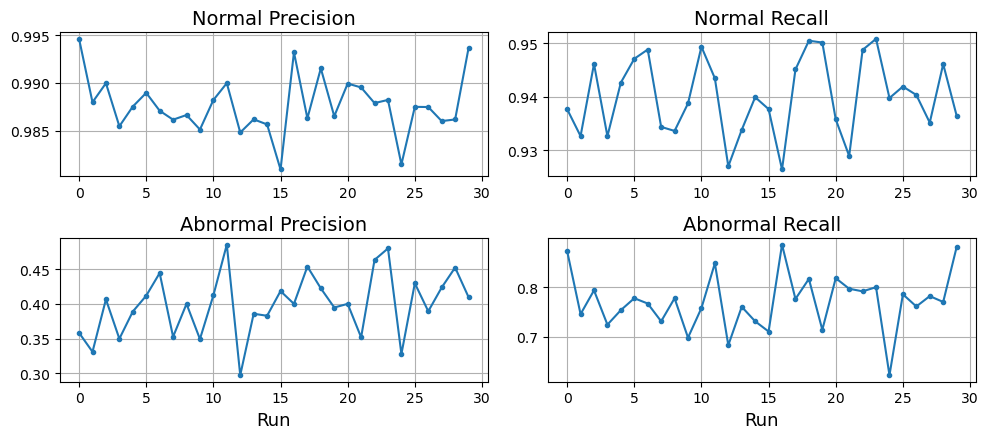

In [45]:
plt.figure(figsize=(10, 4.5))
plt.subplot(2,2,1)
plt.plot([md['pre'][0] for md in metric_list], '.-')
plt.title('Normal Precision', fontsize=14); plt.grid()

plt.subplot(2,2,2)
plt.plot([md['rec'][0] for md in metric_list], '.-')
plt.title('Normal Recall', fontsize=14); plt.grid()

plt.subplot(2,2,3)
plt.plot([md['pre'][1] for md in metric_list], '.-')
plt.title('Abnormal Precision', fontsize=14); plt.grid()
plt.xlabel('Run', fontsize=13)

plt.subplot(2,2,4)
plt.plot([md['rec'][1] for md in metric_list], '.-')
plt.title('Abnormal Recall', fontsize=14); plt.grid()
plt.xlabel('Run', fontsize=13)

plt.tight_layout()
plt.savefig('imbalanced_classification_30_runs.png', transparent=True, dpi=300)

## Mitigation Methods

In [52]:
np.random.seed(RANDOM_SEED)

data = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=DRIFT,
    events_std_alpha=0.1
)

y_true1d = [episode[0].label for episode in data[0]] + [episode[0].label for episode in data[1]]  # ground truths
y_pred1d = [episode[1] for episode in data[0]] + [episode[1] for episode in data[1]]  # predictions
cmatrix = get_confusion_matrix(y_true1d, y_pred1d, n_classes=2)
cmatrix

array([[1294,   86],
       [   7,   48]])

### Method 1: Row-sum balancing

The first approach operates directly on the confusion matrix.

For each class, we scale the corresponding row by a factor that equalizes the row sums -- effectively reweighting each class to have the same number of examples as the majority class.

In [53]:
cmatrix

array([[1294,   86],
       [   7,   48]])

In [56]:
compute_precision_recall(cmatrix, balanced=False, verbose=True)

Class 0 metrics: pre=0.9946 | rec=0.9377
Class 1 metrics: pre=0.3582 | rec=0.8727


{'pre': {0: 0.994619523443505, 1: 0.3582089552238806},
 'rec': {0: 0.9376811594202898, 1: 0.8727272727272727}}

In [57]:
compute_precision_recall(cmatrix, balanced=True, verbose=True)

Class 0 metrics: pre=0.8805 | rec=0.9377
Class 1 metrics: pre=0.9334 | rec=0.8727


{'pre': {0: 0.88048995, 1: 0.9333521}, 'rec': {0: 0.93768114, 1: 0.8727273}}

### Method 2: Repeated stratified sampling

In [102]:
np.random.seed(RANDOM_SEED)

data = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=DRIFT,
    events_std_alpha=0.1
)

In [115]:
coeff = 0.9
sample_size = int(coeff * min(len(data[0]), len(data[1])))
sample_size

49

In [116]:
n_draws = 100

resdict = {
    'cmlist': [],
    'pre': {0: [], 1: []},
    'rec': {0: [], 1: []}
}

for i in range(n_draws):
    normal_indeces = np.random.choice(a=len(data[0]), size=sample_size, replace=True)
    abnormal_indeces = np.random.choice(a=len(data[1]), size=sample_size, replace=True)
    normal_sample = [data[0][i] for i in normal_indeces]
    abnormal_sample = [data[1][i] for i in abnormal_indeces]
    assert len(normal_sample) == len(abnormal_sample), f'{len(normal_sample)} versus {len(abnormal_sample)}'
    
    y_true1d_sample = [episode[0].label for episode in normal_sample] + [episode[0].label for episode in abnormal_sample]  # ground truths
    y_pred1d_sample = [episode[1] for episode in normal_sample] + [episode[1] for episode in abnormal_sample]  # predictions

    # Calculate confusion matrix
    cmatrix_sample = get_confusion_matrix(y_true1d_sample, y_pred1d_sample, n_classes=2)
    resdict['cmlist'].append(cmatrix_sample)

    # Compute metrics on (balanced) sample
    metrics_sample = compute_precision_recall(cmatrix_sample, balanced=False)
    resdict['pre'][0].append(metrics_sample['pre'][0])
    resdict['rec'][0].append(metrics_sample['rec'][0])
    resdict['pre'][1].append(metrics_sample['pre'][1])
    resdict['rec'][1].append(metrics_sample['rec'][1])

#### Cmatrix averaging

Since we obtain a confusion matrix from each subset, we can simply compute the average confusion matrix and get a point estimate for our classification metrics.

In [121]:
cmatrix_stack = np.r_[resdict['cmlist']]
cmatrix_stack.shape

"""
Actual model performance (theoretical)
Class 0 metrics: pre=0.7899 | rec=0.9400
Class 1 metrics: pre=0.9259 | rec=0.7500

Estimated model performance (on balanced data from before - very close to theoretical)
Class 0 metrics: pre=0.7950 | rec=0.9390
Class 1 metrics: pre=0.9255 | rec=0.7578

Subsampling approach - several runs (with various sample sizes and 100 draws)
Using sample size: 27 (coeff: 0.5)
[[25.41  1.59]
 [ 3.54 23.46]]
Class 0 metrics: pre=0.8777 | rec=0.9411
Class 1 metrics: pre=0.9365 | rec=0.8689

Using sample size: 33 (coeff: 0.6)
[[30.98  2.02]
 [ 4.1  28.9 ]]
Class 0 metrics: pre=0.8831 | rec=0.9388
Class 1 metrics: pre=0.9347 | rec=0.8758

Using sample size: 38 (coeff: 0.7)
[[35.94  2.06]
 [ 4.68 33.32]]
Class 0 metrics: pre=0.8848 | rec=0.9458
Class 1 metrics: pre=0.9418 | rec=0.8768

Using sample size: 44 (coeff: 0.8)
[[41.09  2.91]
 [ 5.93 38.07]]
Class 0 metrics: pre=0.8739 | rec=0.9339
Class 1 metrics: pre=0.9290 | rec=0.8652

Using sample size: 49 (coeff: 0.9)
[[45.92  3.08]
 [ 6.29 42.71]]
Class 0 metrics: pre=0.8795 | rec=0.9371
Class 1 metrics: pre=0.9327 | rec=0.8716
"""

cmatrix_mean = np.mean(cmatrix_stack, axis=0)
print(cmatrix_mean)
compute_precision_recall(cmatrix_mean, balanced=False, verbose=True)  # Each confusion matrix is already calculated on a balanced subset

[[45.92  3.08]
 [ 6.29 42.71]]
Class 0 metrics: pre=0.8795 | rec=0.9371
Class 1 metrics: pre=0.9327 | rec=0.8716


{'pre': {0: 0.8795249952116453, 1: 0.9327364053286744},
 'rec': {0: 0.9371428571428572, 1: 0.8716326530612245}}

### Averaging P/R metrics

In [119]:
{
    'pre': {0: np.mean(resdict['pre'][0]), 1: np.mean(resdict['pre'][1])},
    'rec': {0: np.mean(resdict['rec'][0]), 1: np.mean(resdict['rec'][1])}
}

{'pre': {0: 0.8814462540634964, 1: 0.93385046899501},
 'rec': {0: 0.937142857142857, 1: 0.8716326530612245}}

In [91]:
#resdict50 = resdict
#resdict60 = resdict
#resdict70 = resdict
#resdict80 = resdict
resdict90 = resdict

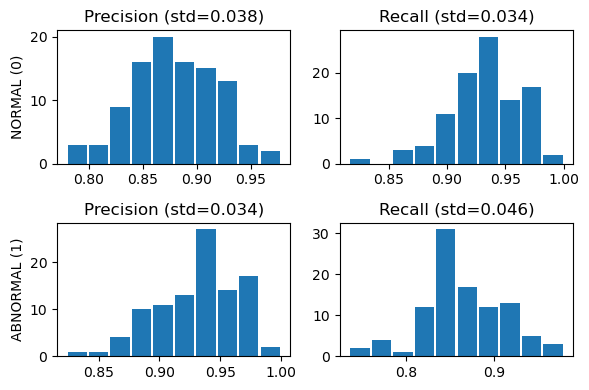

In [89]:
plt = plot_metrics_distributions(resdict90)
plt.savefig('imbalanced_classification_metrics_histogram', transparent=True, dpi=300)

# Data drift

In [212]:
N_DAYS = 14

# Model performance parameters - set using RECALL for NORMAL (0) and ABNORMAL (1)
NORM_REC = 0.94
ABNORM_REC = 0.75
model = AbstractModel(class_recalls=[NORM_REC, ABNORM_REC])

# Daily values for the occurrence of events
ABNORMAL_RATE = 5  # Poisson lambda for abnormal events per day: E(X) = lambda
ABNORMAL_PCT = 0.05

In [213]:
data01 = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=0.01,
    events_std_alpha=0.1
)

In [214]:
data05 = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=0.05,
    events_std_alpha=0.1
)

In [215]:
data10 = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=0.10,
    events_std_alpha=0.1
)

In [216]:
data20 = generate_daily_episodes(
    n_days=N_DAYS,
    normal_recall=NORM_REC,
    abnormal_recall=ABNORM_REC,
    abnormal_rate=ABNORMAL_RATE,
    abnormal_pct=ABNORMAL_PCT,
    drift=0.20,
    events_std_alpha=0.1
)

In [223]:
data = data20

n_draws = 200
sample_size = int(0.8 * min(len(data[0]), len(data[1])))
print('sample size:', sample_size)

resdict = {
    'cmlist': [],
    'pre': {0: [], 1: []},
    'rec': {0: [], 1: []}
}

for i in range(n_draws):
    normal_indeces = np.random.choice(a=len(data[0]), size=sample_size, replace=True)
    abnormal_indeces = np.random.choice(a=len(data[1]), size=sample_size, replace=True)
    normal_sample = [data[0][i] for i in normal_indeces]
    abnormal_sample = [data[1][i] for i in abnormal_indeces]
    assert len(normal_sample) == len(abnormal_sample), f'{len(normal_sample)} versus {len(abnormal_sample)}'
    
    y_true1d_sample = [episode[0].label for episode in normal_sample] + [episode[0].label for episode in abnormal_sample]  # ground truths
    y_pred1d_sample = [episode[1] for episode in normal_sample] + [episode[1] for episode in abnormal_sample]  # predictions

    # Calculate confusion matrix
    cmatrix_sample = get_confusion_matrix(y_true1d_sample, y_pred1d_sample, n_classes=2)
    resdict['cmlist'].append(cmatrix_sample)

    # Compute metrics on (balanced) sample
    metrics_sample = compute_precision_recall(cmatrix_sample, balanced=False)
    resdict['pre'][0].append(metrics_sample['pre'][0])
    resdict['rec'][0].append(metrics_sample['rec'][0])
    resdict['pre'][1].append(metrics_sample['pre'][1])
    resdict['rec'][1].append(metrics_sample['rec'][1])

sample size: 60


In [224]:
#resdict01 = resdict
#resdict05 = resdict
#resdict10 = resdict
resdict20 = resdict

In [211]:
resdict = resdict01

"""
Actual model performance (theoretical)
Class 0 metrics: pre=0.7950 | rec=0.9390
Class 1 metrics: pre=0.9255 | rec=0.7578

Estimated model performance (on balanced data from before - very close to theoretical)
Class 0 metrics: pre=0.7950 | rec=0.9390
Class 1 metrics: pre=0.9255 | rec=0.7578

No Drift
Using sample size: 130 (coeff: 0.8)
{'pre': {0: 0.7341329689338595, 1: 0.8703432795673628},
 'rec': {0: 0.8992956995197563, 1: 0.6744428928821871}}

drift = 0.01
Using sample size: 116 (coeff: 0.8)
{'pre': {0: 0.7120911321288295, 1: 0.8530100783283834},
 'rec': {0: 0.887691881704974, 1: 0.643794032021779}}

drift = 0.05
Using sample size: 128 (coeff: 0.8)
{'pre': {0: 0.7272689187564023, 1: 0.8318104303630574},
 'rec': {0: 0.8639214442902907, 1: 0.6747885930423041}}

drift = 0.10
Using sample size: 116 (coeff: 0.8)
{'pre': {0: 0.700138537141331, 1: 0.7896729086517434},
 'rec': {0: 0.824594435253647, 1: 0.6503976478148893}}

drift = 0.20
Using sample size: 115 (coeff: 0.8)
{'pre': {0: 0.6050128208894842, 1: 0.6569760507228379},
 'rec': {0: 0.7172272594145944, 1: 0.5357071848853499}}
"""

{'pre': {0: 0.7449402151031088, 1: 0.9052255736773352},
 'rec': {0: 0.928203125, 1: 0.679765625}}

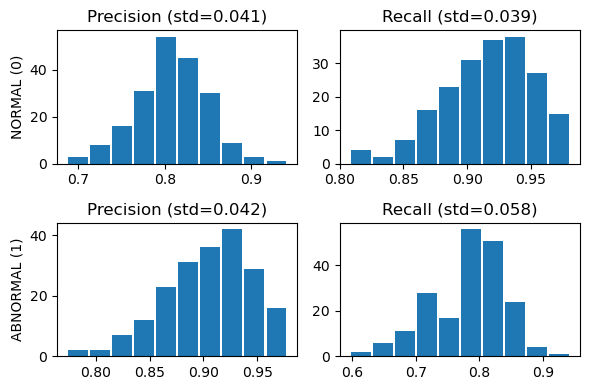

In [225]:
plt = plot_metrics_distributions(resdict01)

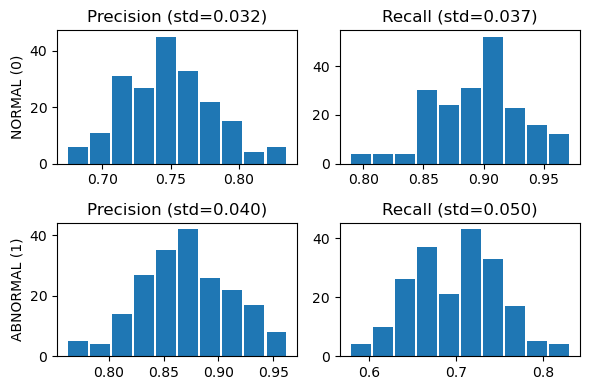

In [226]:
plt = plot_metrics_distributions(resdict05)

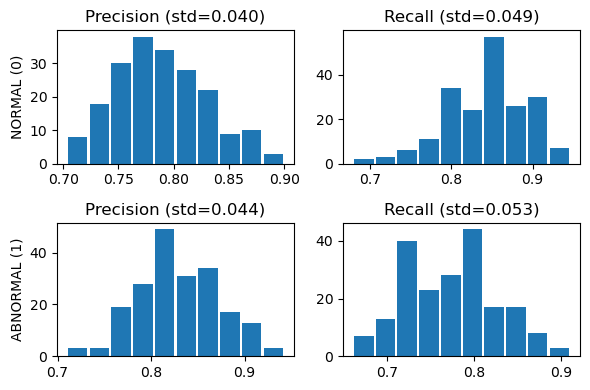

In [227]:
plt = plot_metrics_distributions(resdict10)

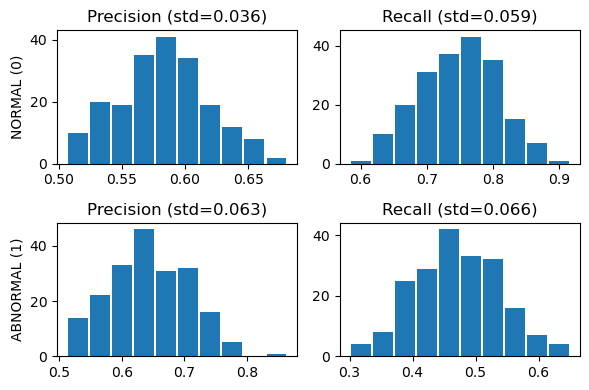

In [228]:
plt = plot_metrics_distributions(resdict20)